
# <span style="color: purple;">Lesson 5 - Making Predictions (Regression)</span>

**Developers:** Brian  |  **Reviewers:** 

---

## <span style="color: purple;">🎯 Learning Objectives</span>

By the end of this lesson, you will have:

- Trained a regression model
- Generated numerical predictions
- Visualised predicted values against true values
- Used prediction error to judge model quality

<div class="alert alert-info">

**How it works:** Click the ▶ button on the top left of each code cell, top to bottom. Read the explanation after you see the output. That's it!

</div>

In [28]:
# Setup cell - run this first
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

print("✓ Ready to go!")

✓ Ready to go!


---

## <span style="color: purple;">🧩 What Problem Are We Solving?</span>

In regression, we predict a number instead of choosing a category.

<div class="alert alert-success">

**Regression**: A machine learning task where the model predicts a continuous numerical value, such as a price, score, or temperature.

</div>

Examples:

| Situation | Input data | Predicted number |
|---|---|---|
| 🏠 House sales | Size, location, rooms | House price |
| ⚡ Energy use | Time, weather | Electricity demand |
| 📚 School revision | Study hours | Test score |

---

## <span style="color: purple;">🧮 Regression in Maths</span>

In regression, the model learns a function that links input to output:

$$
y = f(x)
$$

That means:
- $x$ is the input (what we know)
- $y$ is the output (what we want to predict)
- $f$ is the function learnt by the model

An example would be linear/straight-line regression, where the function is:

$$
\hat{y} = mx + c
$$

The model learns to the optimal $m$ and $c$ so predictions are as close as possible to the real data points.

---

## <span style="color: purple;">Step 1 - Build and Inspect Data 📊</span>

We will use real California housing data: 20,640 houses with information about location, age, size, and occupancy (features) and their median house value (target).

<div class="alert alert-success">

**Feature**: The input values (measurements) used by a model to make a prediction (here: median income, house age, number of rooms, etc.).

</div>

<div class="alert alert-success">

**Target**: The value we want to predict (here: median house price in the area).

</div>

### 📋 What is the "California Housing" datatset?
The California Housing dataset contains information about neighborhoods **house prices in California (target)** from the 1990 census.
Each row is one neighborhood (not one single house), and the model tries to predict the neighborhood’s median house value.

| Target | Name | What it measures |
|---|---|---|
| MedHouseVal | Median House Value | Median house value in the neighborhood (in units of $100,000 and cappped at $500,000) |

The dataset contains **8 location and property features from 20,640 houses**. Here's what each one measures:

| Feature | Name | What it measures |
|---|---|---|
| MedInc | Median Income | Median income of households ($100k) |
| HouseAge | House Age | Median age of houses in the area (years) |
| AveRooms | Average Rooms | Average number of rooms per household |
| AveBedrms | Average Bedrooms | Average number of bedrooms per household |
| Population | Population | Total block group population |
| AveOccup | Average Occupancy | Average household members |
| Latitude | Latitude | Geographic latitude |
| Longitude | Longitude | Geographic longitude |
| MedHouseVal | Target | Median house value ($100k) |

*Note: All features except latitude/longitude are in their original units for easy interpretation.*

<div class="alert alert-info">

**Distribution of house prices visualised:** Run the code cell below to see how the house prices are distributed geographically and numerically.

</div>

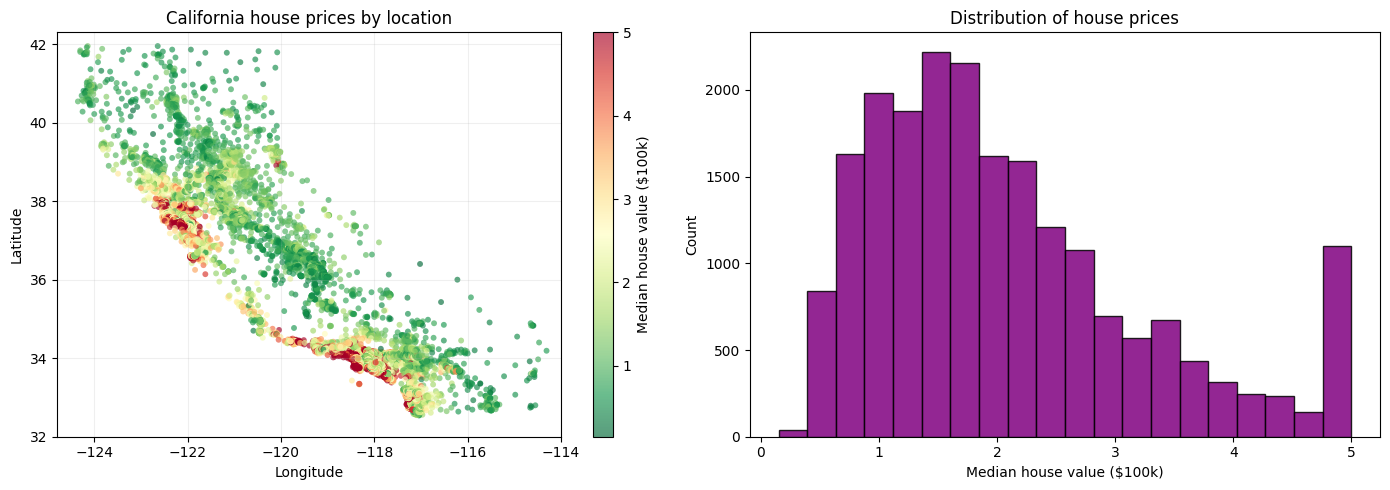

✓ Scatter plots visualised


In [13]:
# Visualize California house prices with scatter plots only
# If this cell is run before the load cell, create data first.
if "data" not in globals():
    housing = fetch_california_housing()
    data = pd.DataFrame(housing.data, columns=housing.feature_names)
    data["MedHouseVal"] = housing.target

# We still visualise one feature, but train on all features later.
target_col = "MedHouseVal"
model_feature_cols = [col for col in data.columns if col != target_col]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Houses by location, colored by price
scatter = axes[0].scatter(
    data["Longitude"],
    data["Latitude"],
    c=data[target_col],
    cmap="RdYlGn_r",
    alpha=0.65,
    s=18,
    edgecolors="none"
)
axes[0].set_title("California house prices by location")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].set_xlim(-124.8, -114.0)
axes[0].set_ylim(32.0, 42.3)
axes[0].grid(True, alpha=0.2)

cbar = plt.colorbar(scatter, ax=axes[0])
cbar.set_label("Median house value ($100k)")

axes[1].hist(data[target_col], bins=20, color="purple", edgecolor="black", alpha=0.85)
axes[1].set_title("Distribution of house prices")
axes[1].set_xlabel("Median house value ($100k)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print("✓ Scatter plots visualised")

<div class="alert alert-info">

### 🗺️ What do these maps show?

The **left scatter** is a geographic view of California with each dot representing a neighborhood. The colour shows the median price in that area: 🟢 **green = cheaper**, 🔴 **red = expensive**.

Notice the patterns:
- **Coastal areas (left side)** tend to be more expensive
- **San Francisco Bay Area and Los Angeles** regions show many high-price points
- **More inland areas** often have lower prices

The model will train on **all 8 features**, but median income is still one of the strongest signals for price.

</div>

### How do the 8 features relate to each other?

A common technique to visualise the relationships between features is to use a **pairplot**.

<div class="alert alert-success">

**Pairplot:** shows how each feature relates to every other feature. The *diagonal* (top-left to bottom-right) shows histograms — the distribution of each feature. The *off-diagonal* cells show scatter plots — how two features relate to each other.

Look for *patterns*: If two features have a strong linear relationship, points will form a tight line. If they're unrelated, points scatter randomly. In the housing data, you might notice that income and house age have different distributions, but they both help predict the price.

</div>

<div class="alert alert-info">

 Run the code cell below to see how the pairplot for the California Houseing dataset features.

</div>

<Figure size 1400x1000 with 0 Axes>

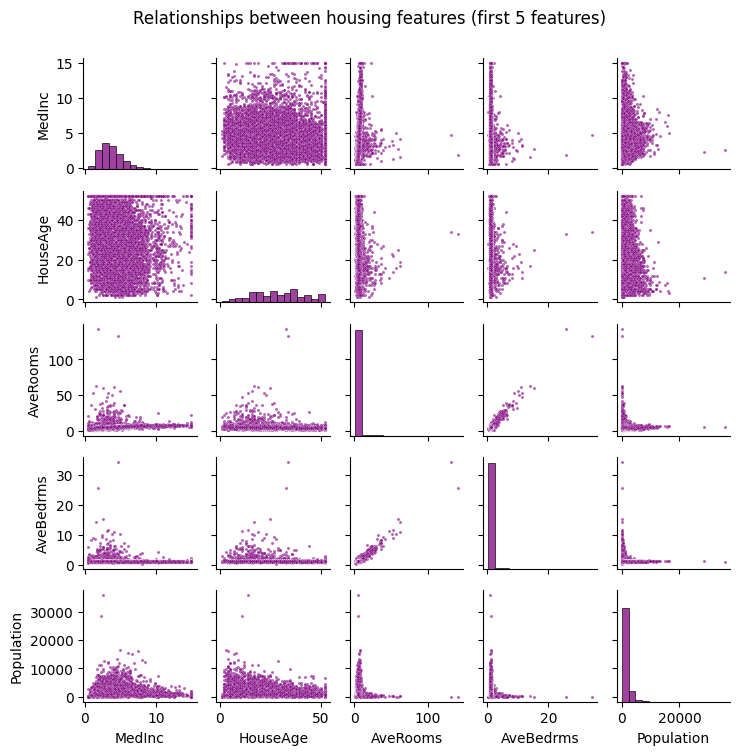

✓ Pairplot visualised


In [15]:
# Create a pairplot to see relationships between all property features
plt.figure(figsize=(14, 10))
sns.pairplot(data.iloc[:, :5], diag_kind="hist", plot_kws={"alpha": 0.6, "s": 5, "color": "purple"}, diag_kws={"bins": 15, "color": "purple"}, size=1.5)
plt.suptitle("Relationships between housing features (first 5 features)", y=1.001)
plt.tight_layout()
plt.show()

print("✓ Pairplot visualised")

<div class="alert alert-info">

### 👀 What do you see?

The scatter plot shows the relationship between median income and house price. The histogram shows the range of house prices in the dataset.

With 20,640 real houses and 8 property features, there is plenty of data for the model to learn from.

</div>

---

## <span style="color: purple;">Step 2 - Train the model</span>

We split the data into a training set and a test set. Then we fit a regression model to the training set.

<div class="alert alert-success">

**Model fitting**: The process where a model learns a pattern from training data.

</div>

In [30]:
# Train using all available input features
if "target_col" not in globals():
    target_col = "MedHouseVal"
if "model_feature_cols" not in globals():
    model_feature_cols = [col for col in data.columns if col != target_col]

X = data[model_feature_cols]
y = data[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", MLPRegressor(hidden_layer_sizes=(32, 16), max_iter=1000, random_state=42))
])
model.fit(X_train, y_train)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Number of input features used: {len(model_feature_cols)} - all features used")
print(f"Final training loss: {model.named_steps['regressor'].loss_:.4f}")
print("✅ Regression model trained")

Training samples: 16512
Test samples: 4128
Number of input features used: 8 - all features used
Final training loss: 0.1297
✅ Regression model trained


This neural-network model learns internal weights across all features to make house-price predictions.

Now we can test the model on housing data it has never seen.

---

## <span style="color: purple;">Step 3 - Make Predictions and Measure Error 🧮</span>

We predict house prices for the test set and compare them to the true prices.

In [33]:
if "feature_col" not in globals():
    feature_col = "MedInc"

y_pred = model.predict(X_test)

# Join predictions to the original test rows and compute error columns
comparison = X_test.copy()
comparison["actual_price"] = y_test.values
comparison["predicted_price"] = y_pred
comparison["error"] = comparison["actual_price"] - comparison["predicted_price"]
comparison["abs_error"] = comparison["error"].abs()

# Show the 10 rows with the largest prediction errors
top_errors = comparison.sort_values("abs_error", ascending=False).head(10)
display(top_errors)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: ${(mae*100000):.2f}")
print(f"Root Mean Squared Error: ${(mse**(1/2)*100000):.2f}")
print(f"R^2 score: {r2:.2f}")
print("✅ Predictions generated and evaluated")

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,actual_price,predicted_price,error,abs_error
6688,0.4999,28.0,7.677419,1.870968,142.0,4.580645,34.15,-118.08,5.00001,1.100008,3.900002,3.900002
19542,1.7679,39.0,5.000000,0.888889,22.0,2.444444,37.63,-120.92,4.50000,1.013952,3.486048,3.486048
14805,7.3669,16.0,11.293103,2.727969,873.0,1.672414,32.68,-117.17,1.87500,5.271258,-3.396258,3.396258
459,1.1696,52.0,2.436000,0.944000,1349.0,5.396000,37.87,-122.25,5.00001,1.612928,3.387082,3.387082
12389,3.7727,24.0,10.953586,1.848101,473.0,1.995781,33.75,-116.43,5.00001,1.864993,3.135017,3.135017
10574,1.9659,6.0,4.795455,1.159091,125.0,2.840909,33.72,-117.70,5.00001,1.991385,3.008625,3.008625
20349,7.3004,32.0,5.724138,0.758621,63.0,2.172414,34.17,-119.08,1.25000,4.161047,-2.911047,2.911047
12069,4.2386,6.0,7.723077,1.169231,228.0,3.507692,33.83,-117.55,5.00001,2.091779,2.908231,2.908231
15624,2.5875,52.0,3.287449,1.020243,629.0,2.546559,37.80,-122.41,5.00001,2.140664,2.859346,2.859346
4630,2.3674,20.0,2.740554,1.047859,2919.0,2.450882,34.07,-118.31,5.00001,2.217796,2.782214,2.782214


Mean Absolute Error: $36372.19
Root Mean Squared Error: $53925.37
R^2 score: 0.78
✅ Predictions generated and evaluated


<div class="alert alert-info">

### 📏 How to read these scores

- Lower **MAE** and **RMSE** means predictions are usually closer to the true values.
- **$\mathbf{R^2}$** tells us how much of the price variation your model explains.

**MAE (Mean Absolute Error):** average absolute prediction error

$$
\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} \left|y_i - \hat{y}_i\right|
$$

**RMSE (Root Mean Squared Error):** square root of average squared error

$$
\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} \left(y_i - \hat{y}_i\right)^2}
$$

**R^2 interpretation guide:**
- **1.00**: perfect predictions
- **0.80 to 1.00**: very strong model
- **0.50 to 0.80**: useful model, but still misses some patterns
- **0.00 to 0.50**: weak model
- **Below 0.00**: worse than predicting the average price every time

</div>


<div class="alert alert-success">

**Prediction error:** The difference between the true value and the predicted value.

**MAE (Mean Absolute Error):** average absolute prediction error - the lower it is, the closer the predictions are to the true values.

**RMSE (Root Mean Squared Error):** square root of average squared error - the lower it is, the closer the predictions are to the true values.

**$\mathbf{R^2}$:**: tells us how much of the price variation your model explains.


</div>

---

## <span style="color: purple;">Step 4 - Visualise True vs Predicted Values 📉</span>

We will use two visuals:

- A scatter plot of true prices vs predicted prices
- A residual plot to see where predictions are too high or too low

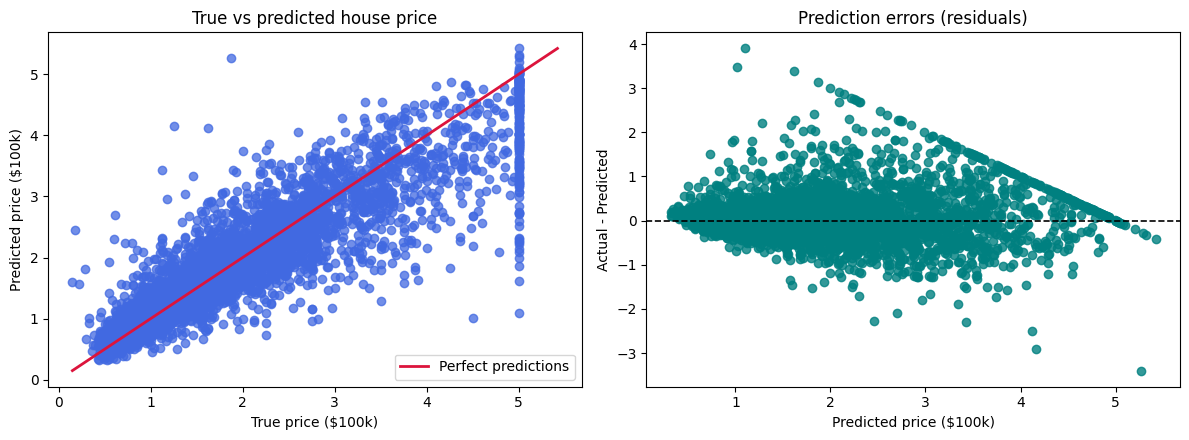

✓ Visual diagnostics displayed


In [34]:
plot_df = pd.DataFrame({
    "actual_price": y_test.values,
    "predicted_price": y_pred
})
residuals = plot_df["actual_price"] - plot_df["predicted_price"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(
    plot_df["actual_price"],
    plot_df["predicted_price"],
    alpha=0.75,
    color="royalblue"
)
min_val = min(plot_df["actual_price"].min(), plot_df["predicted_price"].min())
max_val = max(plot_df["actual_price"].max(), plot_df["predicted_price"].max())
axes[0].plot([min_val, max_val], [min_val, max_val], color="crimson", linewidth=2.0, label="Perfect predictions")
axes[0].set_title("True vs predicted house price")
axes[0].set_xlabel("True price ($100k)")
axes[0].set_ylabel("Predicted price ($100k)")
axes[0].legend()

axes[1].scatter(
    plot_df["predicted_price"],
    residuals,
    color="teal",
    alpha=0.8
)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1.2)
axes[1].set_title("Prediction errors (residuals)")
axes[1].set_xlabel("Predicted price ($100k)")
axes[1].set_ylabel("Actual - Predicted")

plt.tight_layout()
plt.show()

print("✓ Visual diagnostics displayed")

If the line follows the cloud of points reasonably well, the model has learned a useful pattern.

---

## <span style="color: purple;">🧠 Summary</span>

You explored California housing data, trained a neural-network regression model using all 8 input features, generated predictions, and measured model quality with MAE, RMSE, and R^2. You also inspected the rows with the largest prediction errors to understand where the model struggles.

### Key words

| Word | Meaning |
|---|---|
| Regression | Predicting a numerical value |
| Model fitting | Learning patterns from training data |
| MAE | Average absolute prediction error |
| RMSE | Error metric that gives more weight to larger mistakes |
| R^2 | How much of the variation in prices the model explains |

---

## <span style="color: purple;">Quick Quiz</span>

Run the next cell and answer the questions.

In [ ]:
from quiz import run_b05_quiz
run_b05_quiz()